# 2.2. Decision tree behaviour

In [10]:
from anchoring_detection.models import Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn import metrics
from mlxtend.plotting import plot_confusion_matrix
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score, cross_val_predict

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree


dataset = pd.read_pickle('/home/arturo/Documentos/Mooring_anomaly_detector/data/dataframe.pkl')

In [2]:
dataset

,Hs,Tp,Direction,m0_Surge,m0_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.001749,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.008595,1
oc4__Hs1__Tp2__dir1__3,1.21,8.15,0,0.005411,0.005698,1
oc4__Hs1__Tp2__dir1__4,1.21,8.15,0,0.002285,0.003390,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.001852,0
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.018121,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.010878,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.016706,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.002734,0


## Prepare data

The user can apply transformations described in [*models>transform_dataset*](/home/arturo/Documentos/Mooring_anomaly_detector/anchoring_detection/models.py)

In [3]:
drag_models = Models()

In [4]:
X_train_min_max, X_test_min_max, Y_train, Y_test = drag_models.transform_dataset(dataset)

The training set contains the Surge and Sway spectral moments in a 2D array

In [5]:
X_train_min_max

array([[0.00698358, 0.08528962],
       [0.01479205, 0.00191339],
       [0.00537408, 0.10163946],
       [0.07170368, 0.64738316],
       [0.13279204, 0.22928384],
       [0.97379166, 0.44280775],
       [0.02292324, 0.00992097],
       [0.02498603, 0.26900404],
       [0.03661853, 0.00448592],
       [0.46194614, 0.04524715],
       [0.05851568, 0.04525578],
       [0.80010464, 0.28760974],
       [0.00234019, 0.02315467],
       [0.59827887, 0.44251679],
       [0.54892333, 0.06513841],
       [0.59337273, 0.42081638],
       [0.60988548, 0.40667915],
       [0.57558169, 0.42438641],
       [0.67948669, 0.43384154],
       [0.        , 0.02048375],
       [0.61626008, 0.27170729],
       [0.66738549, 0.46234012],
       [0.58478244, 0.42107766],
       [0.02389493, 0.39263281],
       [0.12769059, 0.15162937],
       [0.07700594, 0.10509197],
       [0.61160497, 0.42066791],
       [0.65091093, 0.41372954],
       [0.00869242, 0.01133714],
       [0.01081056, 0.18879129],
       [0.

The approach of training is with supervised learning. It is store the data according two class, **Healthy (0)** and **Draging (1)**

In [6]:
Y_train

oc4__Hs1__Tp5__dir3__1    0
oc4__Hs1__Tp3__dir1__1    0
oc4__Hs1__Tp3__dir1__4    1
oc4__Hs4__Tp5__dir3__1    0
oc4__Hs2__Tp5__dir2__1    0
                         ..
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp3__dir1__3    1
oc4__Hs3__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir1__4    1
oc4__Hs3__Tp5__dir3__1    0
Name: Dragging, Length: 96, dtype: int64

## First training

Check how model perform without hyperparams

In [7]:
model = DecisionTreeClassifier()

In [8]:
model.fit(X_train_min_max,Y_train)

DecisionTreeClassifier()

It is posible to see the tree status

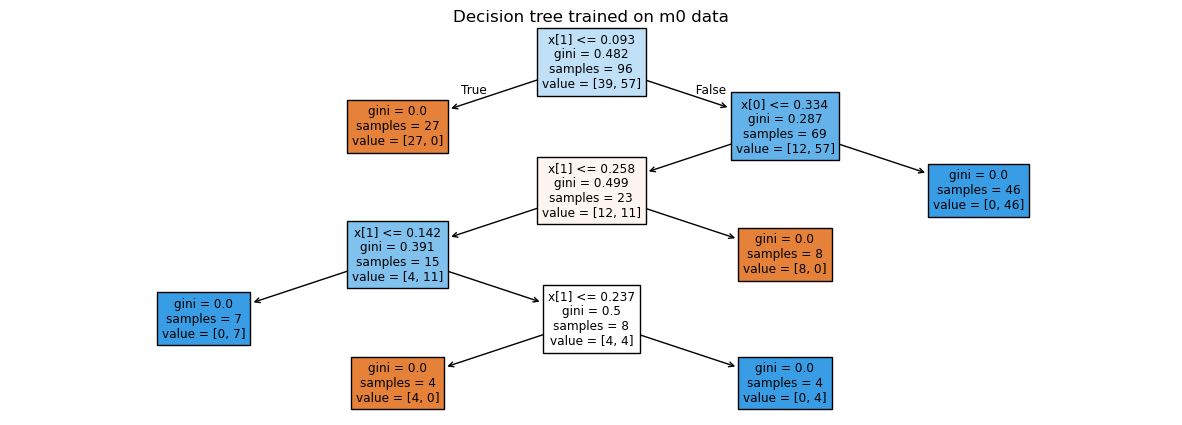

In [9]:
plt.figure(figsize=(15,5))

plot_tree(model, filled=True)
plt.title("Decision tree trained on m0 data")
plt.show()

Due to the orthogonal nature of the decision boundaries in DecisionTree, it very easily falls into overfitting.

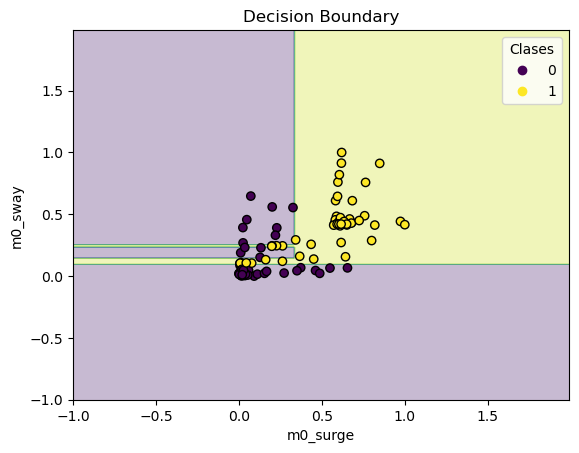

In [13]:
x_min, x_max = X_train_min_max[:, 0].min() - 1, X_train_min_max[:, 0].max() + 1
y_min, y_max = X_train_min_max[:, 1].min() - 1, X_train_min_max[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# predict the class for each mesh point
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundaries
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_train_min_max[:, 0], X_train_min_max[:, 1], c=Y_train, edgecolors='k', marker='o')

plt.title("Decision Boundary")
plt.xlabel("m0_surge")
plt.ylabel("m0_sway")
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()
plt.show()

Can be made cross validation and see the metrics

In [14]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [15]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

In [16]:
df_metrics

,accuracy,precision,recall,f1
0,0.916667,0.945455,0.912281,0.928571


Text(0.5, 1.0, 'Decision_tree')

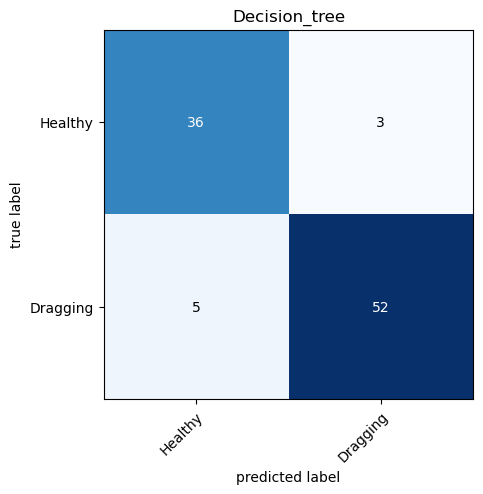

In [17]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision_tree')

## Hyperparams selection

Apply hyperparams to improve the model performance. The main target is reduce the "false healthy states" to the confusion matrix. More information about that in documentation

In [38]:
param_grid = [
    {'max_depth':[2, 3, 4],'min_samples_split':[4,5,6],'min_samples_leaf':[4,5,6],'max_leaf_nodes':[2,3,4]},
]

grid_search = GridSearchCV(model, param_grid, cv=5, scoring= ['accuracy','precision','recall','f1'],refit='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(max_depth=2, max_leaf_nodes=2,
                                              min_samples_leaf=4,
                                              min_samples_split=4),
             param_grid=[{'max_depth': [2, 3, 4], 'max_leaf_nodes': [2, 3, 4],
                          'min_samples_leaf': [4, 5, 6],
                          'min_samples_split': [4, 5, 6]}],
             refit='accuracy', return_train_score=True,
             scoring=['accuracy', 'precision', 'recall', 'f1'])

In [39]:
hyperparams = pd.DataFrame(grid_search.cv_results_)
metric_columns = ['param_max_depth', 'param_min_samples_split', 'param_min_samples_leaf','param_max_leaf_nodes', 'mean_train_accuracy', 'mean_train_precision', 'mean_train_recall', 'mean_train_f1']
hyperparams = hyperparams[metric_columns]

hyperparams

,param_max_depth,param_min_samples_split,param_min_samples_leaf,param_max_leaf_nodes,mean_train_accuracy,mean_train_precision,mean_train_recall,mean_train_f1
0,2,4,4,2,0.880212,0.862616,0.964444,0.905303
1,2,5,4,2,0.880212,0.862616,0.964444,0.905303
2,2,6,4,2,0.880212,0.862616,0.964444,0.905303
3,2,4,5,2,0.880212,0.862616,0.964444,0.905303
4,2,5,5,2,0.880212,0.862616,0.964444,0.905303
...,...,...,...,...,...,...,...,...
76,4,5,5,4,0.968729,0.966922,0.982415,0.973987
77,4,6,5,4,0.968729,0.966922,0.982415,0.973987
78,4,4,6,4,0.968729,0.966922,0.982415,0.973987
79,4,5,6,4,0.968729,0.966922,0.982415,0.973987


In [40]:
grid_search.best_params_

{'max_depth': 3,
 'max_leaf_nodes': 4,
 'min_samples_leaf': 4,
 'min_samples_split': 4}

## New training

Retraining model with hyperparameters

In [41]:
model = DecisionTreeClassifier(max_depth=3,max_leaf_nodes=4,min_samples_leaf=4,min_samples_split=4)

In [42]:
model.fit(X_train_min_max,Y_train)

DecisionTreeClassifier(max_depth=3, max_leaf_nodes=4, min_samples_leaf=4,
                       min_samples_split=4)

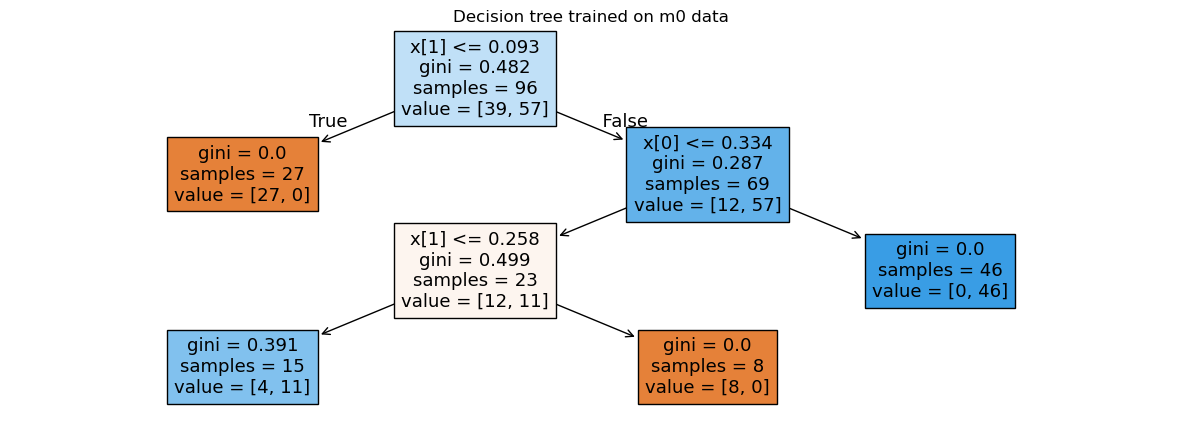

In [43]:
plt.figure(figsize=(15,5))

plot_tree(model, filled=True)
plt.title("Decision tree trained on m0 data")
plt.show()

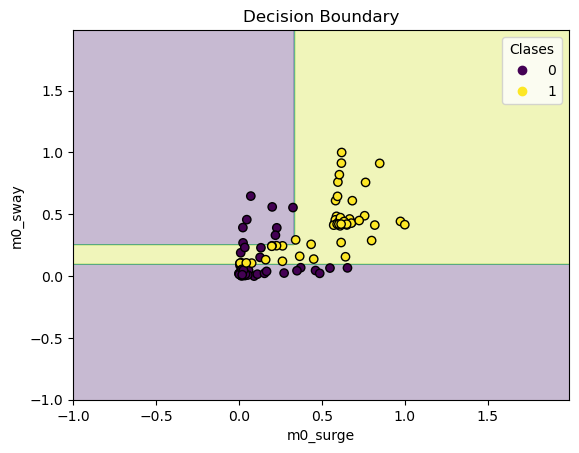

In [44]:
x_min, x_max = X_train_min_max[:, 0].min() - 1, X_train_min_max[:, 0].max() + 1
y_min, y_max = X_train_min_max[:, 1].min() - 1, X_train_min_max[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# predict the class for each mesh point
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundaries
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_train_min_max[:, 0], X_train_min_max[:, 1], c=Y_train, edgecolors='k', marker='o')

plt.title("Decision Boundary")
plt.xlabel("m0_surge")
plt.ylabel("m0_sway")
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()

In [45]:
train_pred = cross_val_predict(model,X_train_min_max, Y_train, cv=5)

In [46]:
cm, df_metrics =drag_models.return_metrics(Y=Y_train, Y_pred=train_pred)

With regard to the first training, the following points should be noted: 

- A reduction in precision was experienced, which is not strictly negative since, considering the low volume of data, the previous record of 97% would be related to an overtraining of the model.

- There was an increase of 5% in the recall, which if you look at the confusion matrix, there are 3 less cases in the false healthy section that ended up in their real class.

In [47]:
df_metrics

,accuracy,precision,recall,f1
0,0.854167,0.877193,0.877193,0.877193


Text(0.5, 1.0, 'Decision tree')

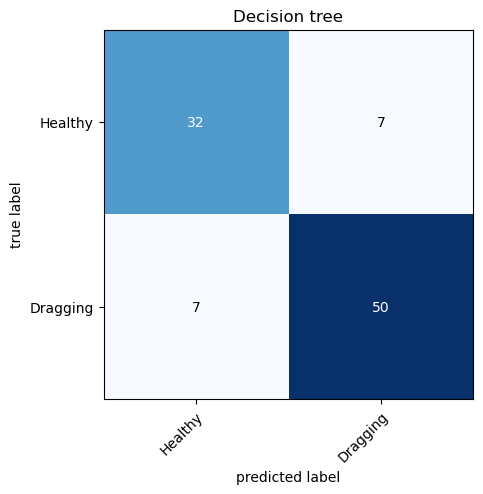

In [49]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

## Predictions

In [50]:
Y_pred_test = model.predict(X_test_min_max)

ATTENTION: Note that you are now working with model test arrays.

In [51]:
cm, df_metrics =drag_models.return_metrics(Y=Y_test, Y_pred=Y_pred_test)

Are few test data, therefore 100% accuracy metrics can be observed. However, for the current data volume, the model trains correctly, with only two ‘false healthy’ cases.

In [52]:
df_metrics

,accuracy,precision,recall,f1
0,0.916667,0.923077,0.923077,0.923077


Text(0.5, 1.0, 'Decision tree')

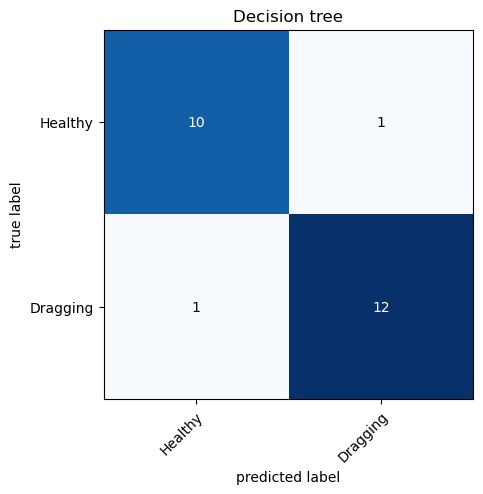

In [53]:
labels = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=labels)
plt.title('Decision tree')

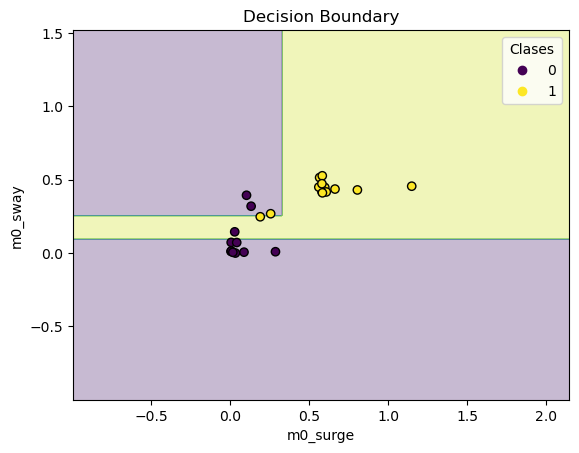

In [55]:
x_min, x_max = X_test_min_max[:, 0].min() - 1, X_test_min_max[:, 0].max() + 1
y_min, y_max = X_test_min_max[:, 1].min() - 1, X_test_min_max[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

# predict the class for each mesh point
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Draw decision boundaries
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_test_min_max[:, 0], X_test_min_max[:, 1], c=Y_test, edgecolors='k', marker='o')

plt.title("Decision Boundary")
plt.xlabel("m0_surge")
plt.ylabel("m0_sway")
plt.legend(*scatter.legend_elements(), title="Clases")
plt.show()